# 1D harmonic oscillator physics-informed neural network (PINN)

This notebook is by Ben Moseley, it is adapted by Gang Xu for PSI 2026 Scientific Machine Learning

This notebook contains the code to reproduce the plots presented in my blog post ["So, what is a physics-informed neural network?"](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/). 

Please read the post for more details!

## Problem overview

The example problem we solve here is the 1D damped harmonic oscillator:
$$
m \dfrac{d^2 x}{d t^2} + \mu \dfrac{d x}{d t} + kx = 0~,
$$
with the initial conditions
$$
x(0) = 1~~,~~\dfrac{d x}{d t} = 0~.
$$
We will focus on solving the problem for the under-damped state, i.e. when 
$$
\delta < \omega_0~,~~~~~\mathrm{with}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$
This has the following exact solution:
$$
x(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$

This problem was inspired by the following blog post: https://beltoforion.de/en/harmonic_oscillator/.

## Workflow overview

>First we will train a standard neural network to interpolate a small part of the solution, using some observed training points from the solution.

>Next, we will train a PINN to extrapolate the full solution outside of these training points by penalising the underlying differential equation in its loss function.


```



### Import libraries <span style="color:blue">(no need to change)

In [17]:
from PIL import Image
import time 

import numpy as np
import torch as tc
import torch.nn as nn
import matplotlib.pyplot as plt
device = 'cuda' if tc.cuda.is_available() else 'cpu'

### Generating training data. write code in the zip line

In [1]:
import numpy as np #provide
from scipy.integrate import solve_ivp #provide
import matplotlib.pyplot as plt #provide

# Parameters
gamma = 0.1        # damping
omega0 = 1.0       # natural frequency
x0 = 1.0           # initial position
v0 = 0.0           # initial velocity
tend=20.0  # scale factor for time
###############################################
tscale = 1 #may want to change it later
###################################################
# Time span
t_span = (0, tend)         # from 0 to 20 seconds you might modify it later
t_eval = np.linspace(0, tend, 500)  # points to evaluate you might modify it later 

# Define first-order system
def damped_oscillator(t, y):
    x, v = y
    dxdt = v 
    ##############################################################
    dvdt =  #### student code the differential equation
    #################################################################
    return [dxdt, dvdt]

# Solve IVP
sol = solve_ivp(damped_oscillator, t_span, [x0, v0], t_eval=t_eval)

x=tc.from_numpy(sol.t).unsqueeze(1).float()


y=tc.from_numpy(sol.y[0]).unsqueeze(1).float()
###########################################################
x_data =x[]  ###choose your data with slicing
y_data =y[]  ### choose your data with slicing
####################################################################3
# Plot
plt.plot(x,y , label="x(t)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement")
plt.title("Damped Oscillator")
plt.grid(True)
plt.legend()
plt.show()

ValueError: Values in `t_eval` are not within `t_span`.

### Define our fully connect network<span style="color:blue">(no need to change)

In [19]:
class FCN(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()]) #* unpacks list into argument 
        self.fch = nn.Sequential(*[##hidden layer
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])##inner Sequential defines one block: linear+activation ##outer Sequential chain the blocks together
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)##last layer
        
    def forward(self, x): ###The forward() method defines the computation of the network., we don't call forward function, the network internally calls it
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Normal neural network

> Next, we train a standard neural network (fully connected network) to fit these training points.

>We find that the network is able to fit the solution very closely in the vicinity of the training points, but does not learn an accurate solution outside of them.

### Run the normal nn, interpret the result <span style="color:blue">(no need to change)

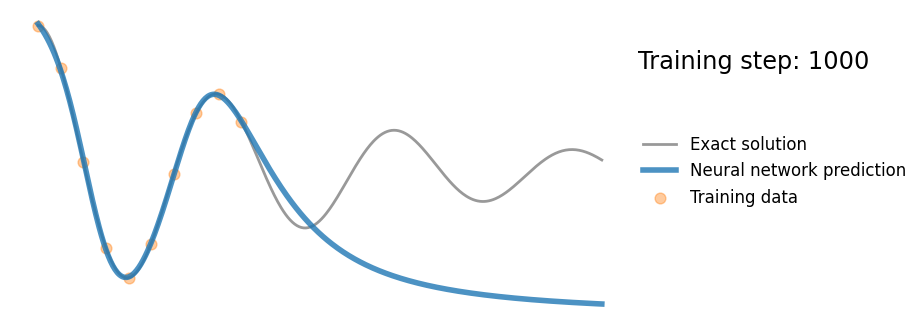

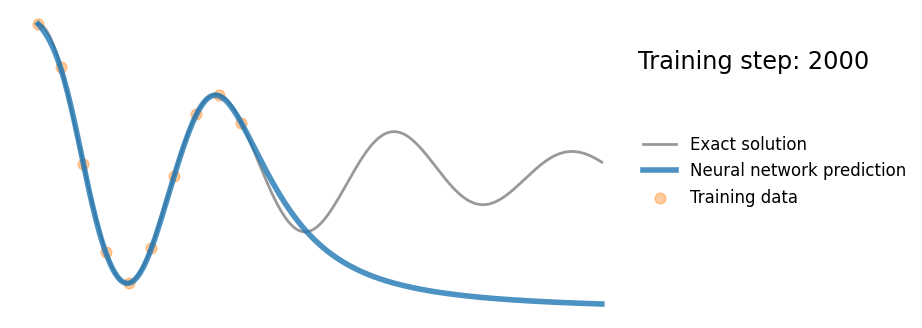

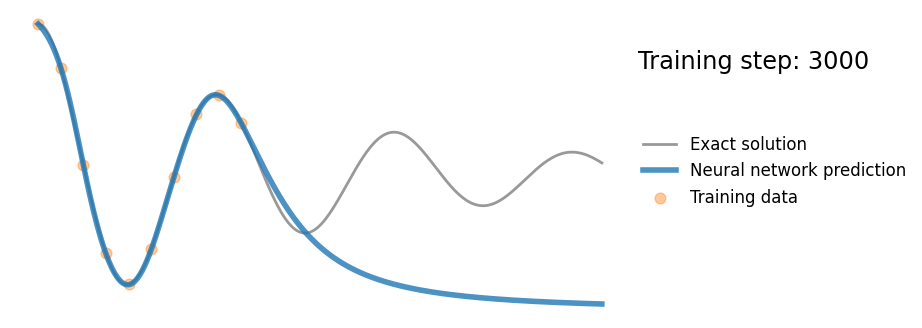

In [20]:
def plot_result(x,y,x_data,y_data,yh,xp=None):##### a very beatiful plot function from Ben
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*tc.ones_like(xp), s=60, color="tab:green", alpha=0.4, 
                    label='Physics loss training locations')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")
    
    
# train standard neural network to fit training data
tc.manual_seed(123)
model = FCN(1,1,32,3) # one input one output, 32 neurons, 3 layers
optimizer = tc.optim.Adam(model.parameters(),lr=1e-3)
for i in range(3000):
    optimizer.zero_grad()
    yh = model(x_data)##############remembered the data you selected?it is used here
    loss = tc.mean((yh-y_data)**2)# use mean squared error
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 1000 == 0: 
        
        yh = model(x).detach()

        plot_result(x,y,x_data,y_data,yh)
        plt.show()
    


## PINN

> Finally, we add the underlying differential equation ("physics loss") to the loss function. 

The physics loss aims to ensure that the learned solution is consistent with the underlying differential equation. This is done by penalising the residual of the differential equation over a set of locations sampled from the domain.

Here we evaluate the physics loss at 30 points uniformly spaced over the problem domain $([0,20])$. We can calculate the derivatives of the network solution with respect to its input variable at these points using `pytorch`'s autodifferentiation features, and can then easily compute the residual of the differential equation using these quantities.

### Building a PINN, where are the parameters trained? <span style="color:blue">(no need to change)

In [22]:
import math
class FCNPh(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.gamma_train = nn.Parameter(tc.tensor(0.0))
        self.omega0_train = nn.Parameter(tc.tensor(0.0))
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x



### Now time to train our PINN 

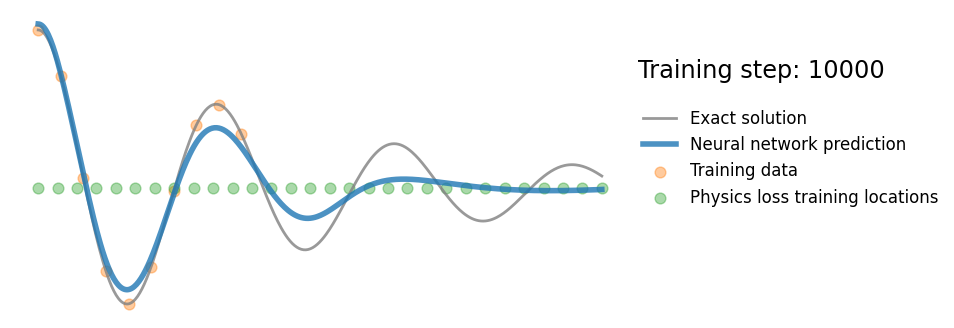

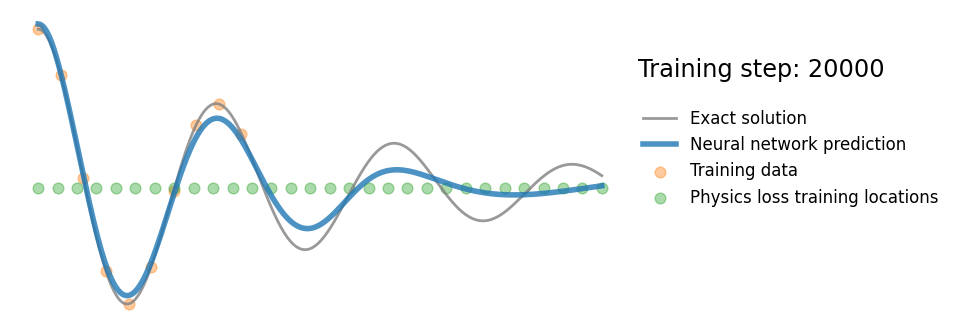

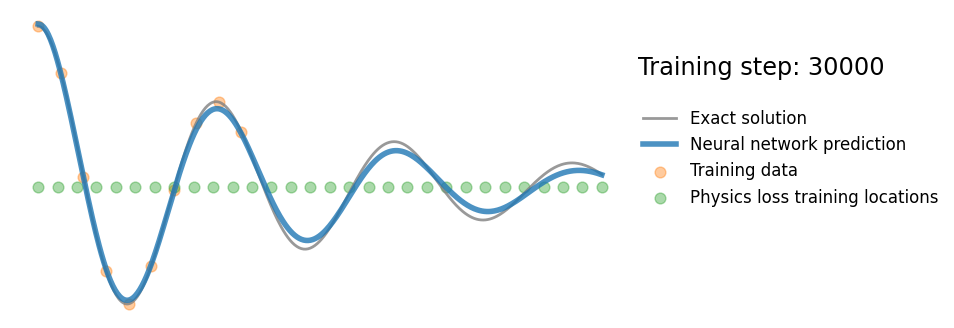

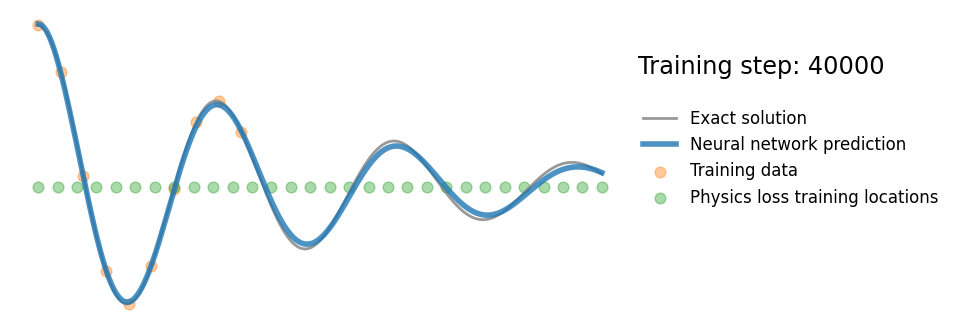

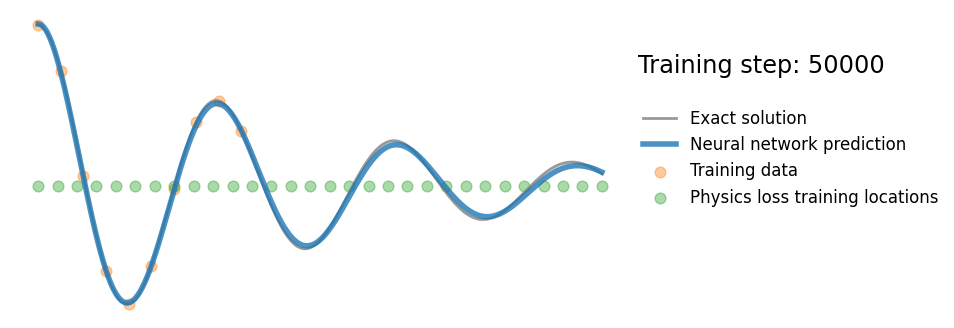

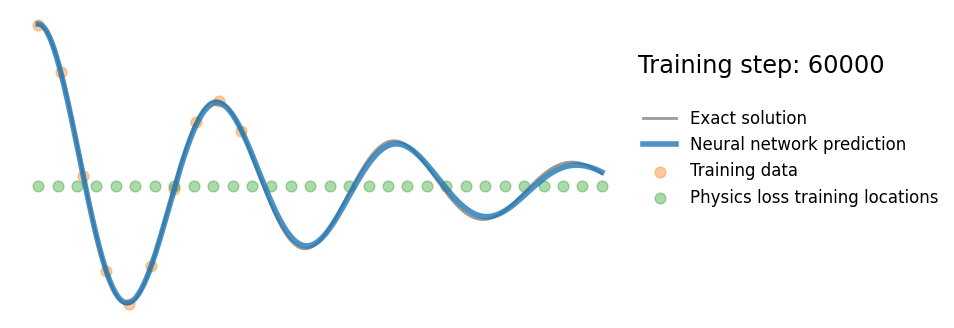

gamma: 0.10511444509029388 omega: 0.992535412311554


In [23]:
###########################################
num_phy =   ######choose how many collation points you want
##############################################
x_physics = tc.linspace(0,tend,num_phy).unsqueeze(1).requires_grad_(True)# sample locations over the problem domain


tc.manual_seed(123)
model = FCNPh(1,1,32,3)
optimizer = tc.optim.Adam(model.parameters(),lr=3e-4)
#files = []
loss1_list = []
loss2_list = []
loss3_list = []
loss_list=[]
gamma_list=[]
omega_list=[]
for i in range(60000):
    optimizer.zero_grad()
    ###########################################################
    gamma=model.gamma_train
    omega0=model.omega0_train  ##you may want to modify this later
    ############################################################3
    # compute the "data loss"
    yh = model(x_data)
    loss1 = tc.mean((yh-y_data)**2)####MSE data lost
    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = tc.autograd.grad(yhp, x_physics, tc.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = tc.autograd.grad(dx,  x_physics, tc.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    ########################################################################################
    physics =##### student write code to compute physics loss, you might have to change it later
################################################################################################3
    lambdaphy =  1e-2 #play with this parameter
    loss2 = lambdaphy*tc.mean(physics**2)
   # print(dx,dx2,loss2,loss1)
    # backpropagate joint loss
    lambdaic = 1 #play with this parameter
    ####################################################################################################
    loss3 = lambdaic*abs(yhp[0]-x0)**2+abs(dx[0]-v0)**2 ### student write code to compute initial penalty
    ######################################################################################################3
    loss = loss1 + loss2 + loss3# add three loss terms together
 
    loss1_list.append(loss1.item())
    loss2_list.append(loss2.item())
    loss3_list.append(loss3.item())
    loss_list.append(loss.item())
    gamma_list.append(model.gamma_train.item())
    omega_list.append(model.omega0_train.item())
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 10000 == 0: 
        
        yh = model(x).detach()
        xp = x_physics.detach()
        
        plot_result(x,y,x_data,y_data,yh,xp)
        
   #     file = "plots/pinn_%.8i.png"%(i+1)
    #    plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
     #   files.append(file)
        
       
        plt.show()
         #   print(loss1,loss2,loss3)
        print("gamma:", tc.exp(model.gamma_train).item(),"omega:", tc.exp(model.omega0_train).item())
      
           
# save_gif_PIL("pinn.gif", files, fps=20, loop=0)

In [18]:
 yh = model(x_data)

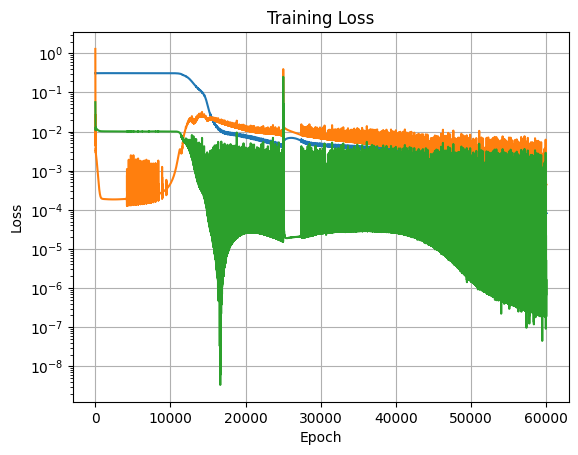

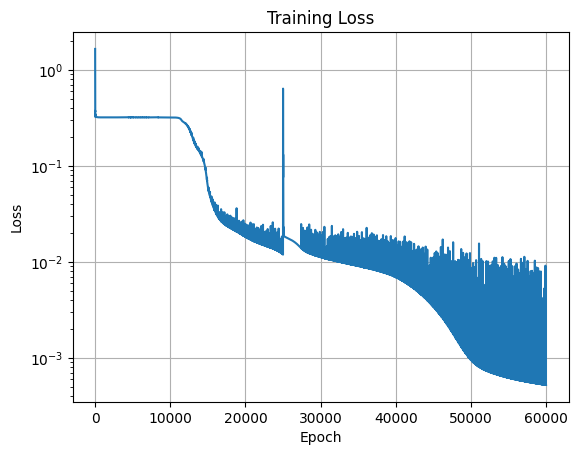

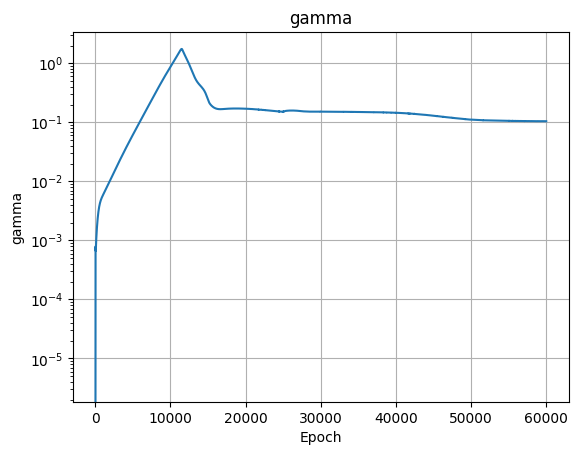

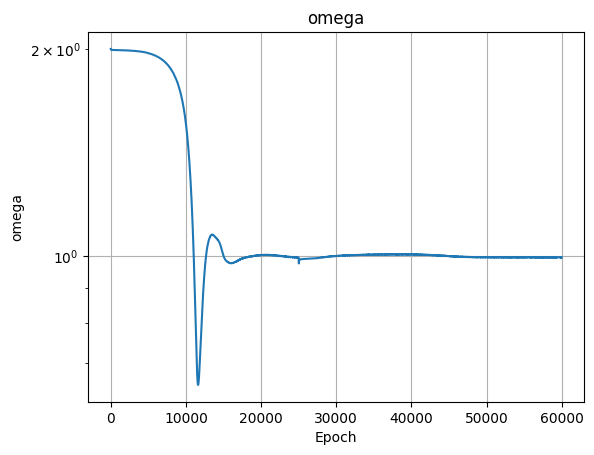

In [64]:
plt.figure()
plt.plot(loss1_list)
plt.plot(loss2_list)
plt.plot(loss3_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.yscale("log")  # highly recommended for PINNs
plt.grid(True)
plt.show()
plt.figure()
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.yscale("log")  # highly recommended for PINNs
plt.grid(True)
plt.show()
plt.figure()
plt.plot(gamma_list)
plt.xlabel("Epoch")
plt.ylabel("gamma")
plt.title("gamma")
plt.yscale("log")  # highly recommended for PINNs
plt.grid(True)
plt.show()
plt.figure()
plt.plot(omega_list)
plt.xlabel("Epoch")
plt.ylabel("omega")
plt.title("omega")
plt.yscale("log")  # highly recommended for PINNs
plt.grid(True)
plt.show()

### how stable is our PINN against random noise? A play ground

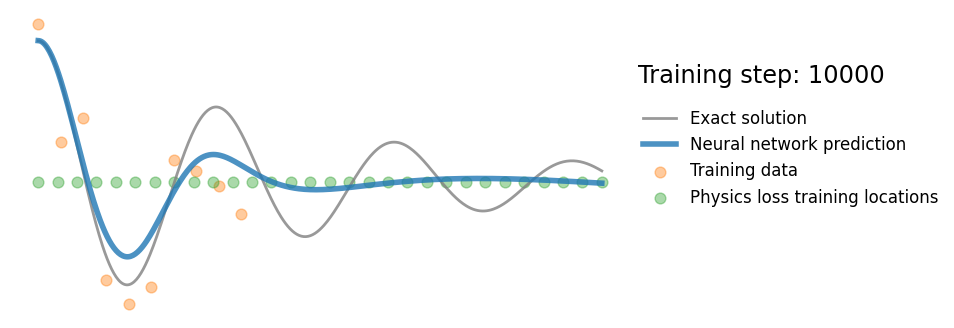

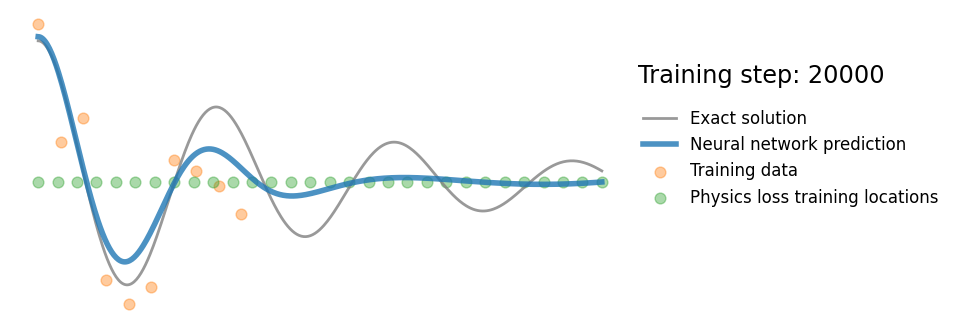

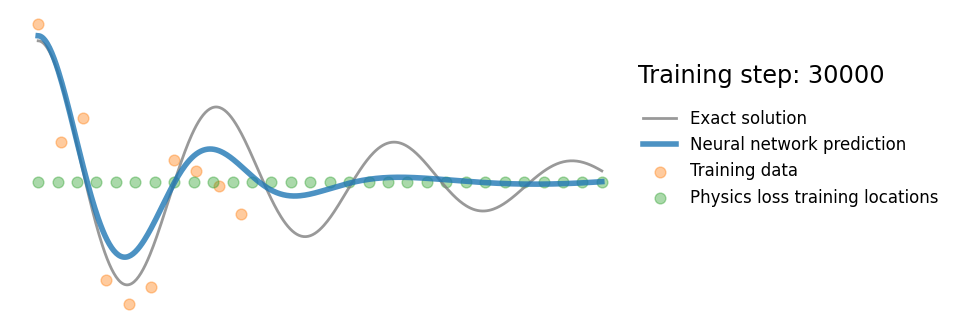

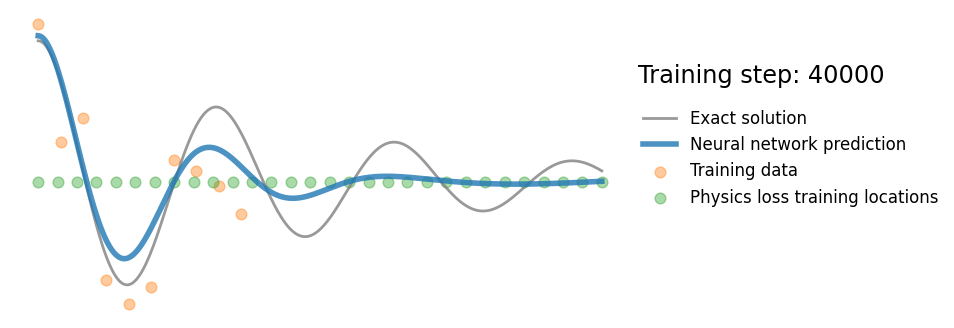

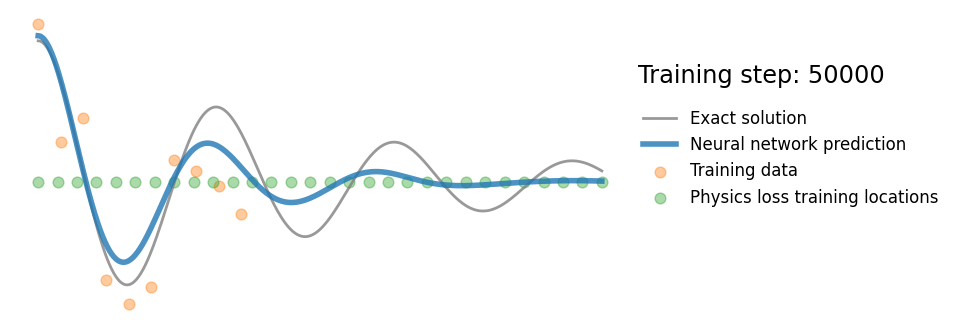

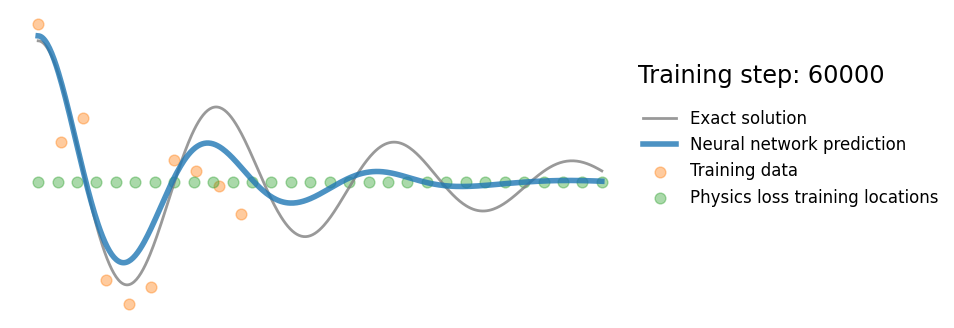

gamma: 0.20673233270645142 omega: 1.060561180114746


In [16]:
x_physics = tc.linspace(0,1,30).unsqueeze(1).requires_grad_(True)# sample locations over the problem domain


tc.manual_seed(135)
model = FCNPh(1,1,32,3)
optimizer = tc.optim.Adam(model.parameters(),lr=3e-4)
#files = []
loss1_list = []
loss2_list = []
loss3_list = []
loss_list=[]
gamma_list=[]
omega_list=[]
y_noise = (tc.randn(y_data.shape[0])*0.1).unsqueeze(1)
y_data = y_data+y_noise
for i in range(60000):
    optimizer.zero_grad()
    gamma=tc.exp(model.gamma_train)
    omega0=tc.exp(model.omega0_train)
    
    # compute the "data loss"
    yh = model(x_data)
    loss1 = tc.mean((yh-y_data)**2)# use mean squared error
    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = tc.autograd.grad(yhp, x_physics, tc.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = tc.autograd.grad(dx,  x_physics, tc.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx2 + 2*gamma*dx*tscale + omega0**2*yhp*tscale**2# computes the residual of the 1D harmonic oscillator differential equation
    if i<25000: 
        lambdaphy = 1e-4
    else:    
        lambdaphy = 2e-4
  #  lambdaphy =  1e-4
    loss2 = lambdaphy*tc.mean(physics**2)
   # print(dx,dx2,loss2,loss1)
    # backpropagate joint loss
    loss3 = 0.1*abs(yhp[0]-x0)**2+abs(dx[0]-v0)**2
    loss = loss1 + loss2 + loss3# add two loss terms together
 #   print(loss1,loss2,loss3,loss)
    loss1_list.append(loss1.item())
    loss2_list.append(loss2.item())
    loss3_list.append(loss3.item())
    loss_list.append(loss.item())
    gamma_list.append(model.gamma_train.item())
    omega_list.append(model.omega0_train.item())
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 10000 == 0: 
        
        yh = model(x).detach()
        xp = x_physics.detach()
        
        plot_result(x,y,x_data,y_data,yh,xp)
        
   #     file = "plots/pinn_%.8i.png"%(i+1)
    #    plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
     #   files.append(file)
        
       
        plt.show()
         #   print(loss1,loss2,loss3)
print("gamma:", tc.exp(model.gamma_train).item(),"omega:", tc.exp(model.omega0_train).item())
      
           
# save_gif_PIL("pinn.gif", files, fps=20, loop=0)